# Lab: Phân loại ảnh CIFAR-10 bằng CNN (train/test = 80/20)

## Bước 1 — Cài & import thư viện

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Bước 2 — Tải CIFAR-10 và chia 80/20 cho train/test

In [3]:
(x_train0, y_train0), (x_test0, y_test0) = keras.datasets.cifar10.load_data()
X = np.concatenate([x_train0, x_test0], axis=0)
y = np.concatenate([y_train0, y_test0], axis=0).ravel()

# Chia 80/20 cho train/test (giữ tỉ lệ lớp)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1586s 9us/step


((48000, 32, 32, 3), (12000, 32, 32, 3), (48000,), (12000,))

## Bước 3 — Khám phá nhanh dữ liệu

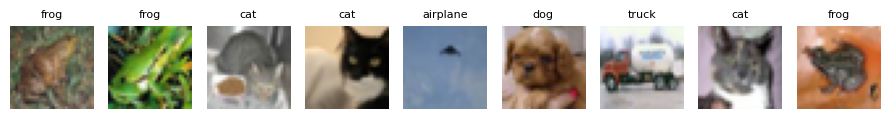

In [5]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(9,3))
for i in range(9):
    plt.subplot(1,9,i+1)
    plt.imshow(X_train[i])
    plt.axis('off')
    plt.title(class_names[y_train[i]], fontsize=8)
plt.tight_layout()
plt.show()


## Bước 4 — Tiền xử lý (normalize & one-hot)

In [6]:
# Về float và scale về [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32")  / 255.0

# One-hot cho nhãn
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes)


## Bước 5 — Xây CNN “nhỏ gọn kiểu VGG”

In [4]:
def build_cnn(input_shape=(32,32,3), num_classes=10):
    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Block 2
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Block 3
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Classifier
    x = layers.Flatten()(x)            # như phần 8.2.3 của tài liệu
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model

model = build_cnn()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 814,122 (3.11 MB)

 Trainable params: 814,122 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

## Bước 6 — Compile & Train (có EarlyStopping)

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train_cat,
    validation_split=0.1,      # trích 10% của train làm validation
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/30
675/675 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.3697 - loss: 1.7075 - val_accuracy: 0.5427 - val_loss: 1.2259
Epoch 2/30
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5716 - loss: 1.2041 - val_accuracy: 0.6283 - val_loss: 1.0155
Epoch 3/30
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6533 - loss: 0.9946 - val_accuracy: 0.6802 - val_loss: 0.8854
Epoch 4/30
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6974 - loss: 0.8647 - val_accuracy: 0.7237 - val_loss: 0.7838
Epoch 5/30
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7370 - loss: 0.7544 - val_accuracy: 0.7165 - val_loss: 0.8009
Epoch 6/30
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7684 - loss: 0.6658 - val_accuracy: 0.7540 - val_loss: 0.7027
Epoch 7/30
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7903 - loss: 0.5947 - val_accuracy: 0.7515 - val_loss: 0.7229
Epoch 8/30
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8128 - loss: 0.5327 - val_accuracy:

## Bước 7 — Đánh giá trên test 20%

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test accuracy: {test_acc:.4f} - Test loss: {test_loss:.4f}")


Test accuracy: 0.7707 - Test loss: 0.6965


## Bước 8 — Báo cáo phân loại & Ma trận nhầm lẫn

              precision    recall  f1-score   support

    airplane       0.78      0.81      0.79      1200
  automobile       0.84      0.92      0.88      1200
        bird       0.69      0.65      0.67      1200
         cat       0.63      0.57      0.60      1200
        deer       0.73      0.70      0.71      1200
         dog       0.72      0.65      0.68      1200
        frog       0.80      0.84      0.82      1200
       horse       0.77      0.83      0.80      1200
        ship       0.86      0.88      0.87      1200
       truck       0.85      0.87      0.86      1200

    accuracy                           0.77     12000
   macro avg       0.77      0.77      0.77     12000
weighted avg       0.77      0.77      0.77     12000



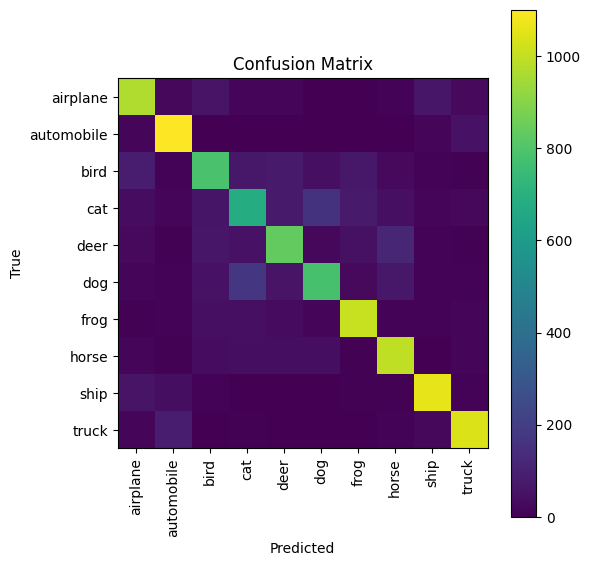

In [9]:
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90)
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout()
plt.show()


## Bước 9 — Thử dự đoán một vài ảnh

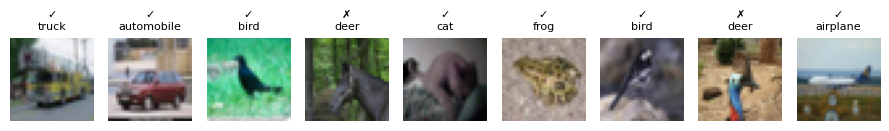

In [10]:
idx = np.random.choice(len(X_test), size=9, replace=False)
images, labels, preds = X_test[idx], y_test[idx], y_pred[idx]

plt.figure(figsize=(9,3))
for i in range(9):
    plt.subplot(1,9,i+1)
    plt.imshow(images[i])
    ok = "✓" if labels[i]==preds[i] else "✗"
    plt.title(f"{ok}\n{class_names[preds[i]]}", fontsize=8)
    plt.axis('off')
plt.tight_layout(); plt.show()


## Bước 10 — Lưu và nạp lại mô hình (tùy chọn)

In [11]:
model.save("cifar10_cnn.h5")
print("Đã lưu -> cifar10_cnn.h5")

# Thử nạp lại
reloaded = keras.models.load_model("cifar10_cnn.h5")
print("Tải lại OK. Kiểm tra nhanh:", reloaded.evaluate(X_test, y_test_cat, verbose=0))


Đã lưu -> cifar10_cnn.h5
Tải lại OK. Kiểm tra nhanh: [0.6964681148529053, 0.7706666588783264]
